# ICOS data objects with `icoscp_core`: the citable route

The classic way into ICOS data: every released dataset is a **data object**
with a landing page, a DOI-backed citation, licence and provenance. The
[`icoscp_core`](https://pypi.org/project/icoscp-core/) library finds objects
and reads their columns directly from the Carbon Portal.

- **Discovery and metadata are anonymous** (everything up to the citation).
- **Reading data columns needs a free
  [Carbon Portal account](https://cpauth.icos-cp.eu/)** — on the ICOS
  JupyterHub the credentials are already in your home directory; elsewhere run
  `bootstrap.fromPasswordFile("~/.icoscp_auth")` once.

When to choose this route: your paper cites *the* released file. For long
merged time series, filtered extracts and live stores, see notebooks 02–05
(Zarr + REST).

In [1]:
from icoscp_core.icos import auth, meta, data

stations = meta.list_stations()                     # all domains, cached SPARQL
print(len(stations), "stations;", len(meta.list_datatypes()), "data types")
cbw = next(s for s in stations if s.id == "CBW")
print(cbw.name, "→", cbw.uri)

470 stations; 128 data types
Cabauw → http://meta.icos-cp.eu/resources/stations/AS_CBW


In [2]:
# One released object per intake height — a tall tower is not one time series.
ATC_CO2_RELEASE = "http://meta.icos-cp.eu/resources/cpmeta/atcCo2L2DataObject"
dobjs = sorted(meta.list_data_objects(datatype=ATC_CO2_RELEASE, station=cbw.uri),
               key=lambda o: o.filename)
for o in dobjs:
    print(o.filename, f"({o.size_bytes/1e3:.0f} kB)")

ICOS_ATC_L2_L2-2026.1_CBW_127.0_CTS_CO2.zip (756 kB)
ICOS_ATC_L2_L2-2026.1_CBW_207.0_CTS_CO2.zip (792 kB)
ICOS_ATC_L2_L2-2026.1_CBW_27.0_CTS_CO2.zip (767 kB)
ICOS_ATC_L2_L2-2026.1_CBW_67.0_CTS_CO2.zip (763 kB)


In [3]:
# The citation for your paper — metadata, still anonymous:
lite = next(o for o in dobjs if "_207" in o.filename)      # the 207 m intake
dobj = meta.get_dobj_meta(lite.uri)                        # full object metadata
print(dobj.references.citationString)

Frumau, A., Hensen, A. (2026). ICOS ATC CO2 Release from Cabauw (207.0 m), 2021-09-30–2026-03-31, ICOS RI, https://hdl.handle.net/11676/0iQnqctEYJ-jM0ERHkXmVUO8


In [4]:
# Reading the columns needs the (free) account token — ~0.1 s, no file written:
import pandas as pd
cols = data.get_columns_as_arrays(dobj, ["TIMESTAMP", "co2"])
s = pd.Series(cols["co2"], index=pd.to_datetime(cols["TIMESTAMP"])).dropna()
print(f"{len(s):,} values, {s.index[0]:%Y-%m-%d} → {s.index[-1]:%Y-%m-%d}")

39,221 values, 2021-09-30 → 2026-03-31


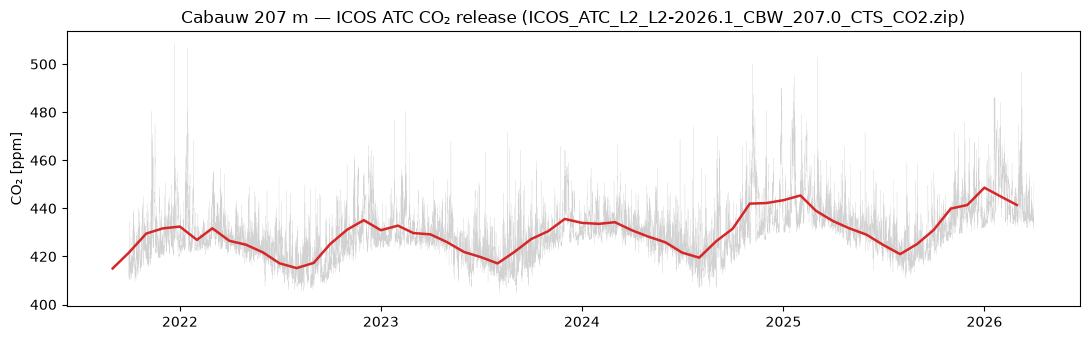

In [5]:
import matplotlib.pyplot as plt

monthly = s.resample("MS").mean()
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(s.index, s.values, lw=0.15, alpha=0.35, color="tab:gray")
ax.plot(monthly.index, monthly.values, lw=1.8, color="tab:red")
ax.set_ylabel("CO₂ [ppm]")
ax.set_title(f"Cabauw 207 m — ICOS ATC CO₂ release ({lite.filename})")
fig.tight_layout()

## What columns exist? The portal's ingested binary format

On upload, the Carbon Portal **ingests every tabular release into a typed
binary column store** — that is what the portal's landing-page preview plots,
and what `get_columns_as_arrays` reads: only the columns you ask for stream
back, no file download, no CSV parsing. The available (previewable) columns
and their value types are part of the object metadata:

In [6]:
for c in dobj.specificInfo.columns:
    vt = c.valueType.self.label if c.valueType else ""
    flag = "  (flag column)" if getattr(c, "isFlagFor", None) else ""
    print(f"{c.label:14s} {vt}{flag}")

TIMESTAMP      time instant, UTC
co2            CO2 (dry air mole fraction)
Stdev          standard deviation of gas mole fraction
Flag           quality flag  (flag column)
NbPoints       number of points


Because the reads are column-wise from the binary store, fetching many
objects is one cheap call — all four Cabauw intake heights at once:

4 objects, 157,824 rows in 0.35 s


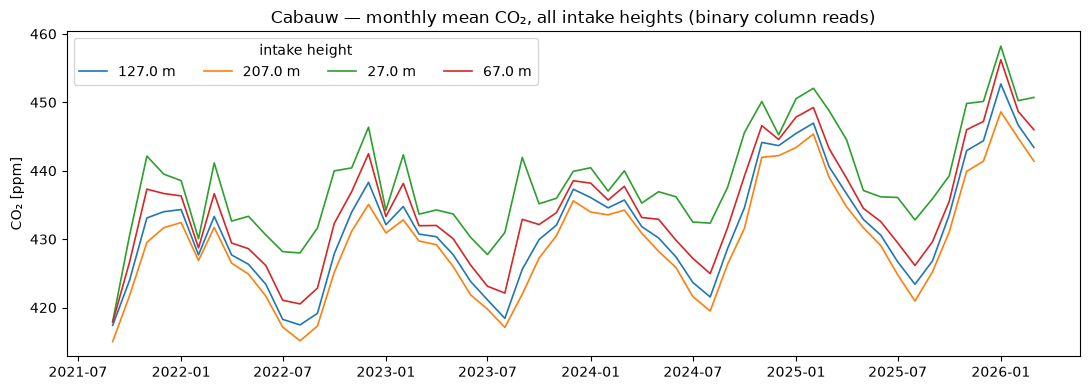

In [7]:
import time, matplotlib.pyplot as plt

t0 = time.perf_counter()
per_height = list(data.batch_get_columns_as_arrays(dobjs, ["TIMESTAMP", "co2"]))
n = sum(len(c["co2"]) for _, c in per_height)
print(f"{len(per_height)} objects, {n:,} rows in {time.perf_counter()-t0:.2f} s")

fig, ax = plt.subplots(figsize=(11, 4))
for o, c in per_height:
    hs = pd.Series(c["co2"], index=pd.to_datetime(c["TIMESTAMP"])).dropna()
    label = o.filename.split("_CBW_")[1].split("_")[0] + " m"
    ax.plot(hs.resample("MS").mean(), lw=1.2, label=label)
ax.set_ylabel("CO₂ [ppm]"); ax.legend(title="intake height", ncols=4)
ax.set_title("Cabauw — monthly mean CO₂, all intake heights (binary column reads)")
fig.tight_layout()

Use `data.save_to_folder(dobj, ".")` when you want the released file
itself. Rule of thumb: **citation → portal object (this notebook), analysis →
Zarr (notebooks 02/04), quick filtered extract → REST (notebook 03), big
grids → OPeNDAP (notebook 06), provenance → passports (notebook 07).**